## 练习 3.1

1. 假设我们有一些数据$x_1, \ldots, x_n \in \mathbb{R}$。我们的目标是找到一个常数$b$，使得最小化$\sum_i (x_i - b)^2$。
    1. 找到最优值$b$的解析解。
    1. 这个问题及其解与正态分布有什么关系?
1. 推导出使用平方误差的线性回归优化问题的解析解。为了简化问题，可以忽略偏置$b$（我们可以通过向$\mathbf X$添加所有值为1的一列来做到这一点）。
    1. 用矩阵和向量表示法写出优化问题（将所有数据视为单个矩阵，将所有目标值视为单个向量）。
    1. 计算损失对$w$的梯度。
    1. 通过将梯度设为0、求解矩阵方程来找到解析解。
    1. 什么时候可能比使用随机梯度下降更好？这种方法何时会失效？
1. 假定控制附加噪声$\epsilon$的噪声模型是指数分布。也就是说，$p(\epsilon) = \frac{1}{2} \exp(-|\epsilon|)$
    1. 写出模型$-\log P(\mathbf y \mid \mathbf X)$下数据的负对数似然。
    1. 请试着写出解析解。
    1. 提出一种随机梯度下降算法来解决这个问题。哪里可能出错？（提示：当我们不断更新参数时，在驻点附近会发生什么情况）请尝试解决这个问题。


## Solutions:
### 1.1 
Consider the gradient of the objective function $f(\vec{x}, b)$ with respect to $b$:
$$
\frac{\partial f}{\partial b} = 2(n·b - \sum_i x_i)
$$
So to minimize $f$, we just need to let the gradient to be 0, i.e.:
$$
b = \frac{\sum_i x_i}{n}
$$

### 1.2
Assume that the noise $\epsilon$ follows a normal distribution with mean $b$ and variance $\sigma^2$, i.e. $\epsilon \sim \mathcal{N}(b, \sigma^2)$. Then the likelihood of the data can be written as:
$$
P(\mathbf{x} \mid b) = \prod_i P(x_i \mid b) = \prod_i \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x_i - b)^2}{2\sigma^2}\right)
$$
So the negative log-likelihood can be written as:
$$
-\log P(\mathbf{x} \mid b) = \sum_i \frac{(x_i - b)^2}{2\sigma^2} + \frac{n}{2}\log(2\pi\sigma^2)
$$
Minimizing the negative log-likelihood is equivalent to minimizing $\sum_i (x_i - b)^2$.

### 2.1 
We assume:
+ Data: A $n\times m$ matrix $\mathbf{X}$.
+ Labels:
  + Predicted labels: $\hat{\mathbf{y}} = \mathbf{X}\mathbf{w}$.
  + True labels: $\mathbf{y}$.
So the objective function can be written as:
$$
SSE = \sum_i (y_i - \hat{y}_i)^2 = ||\mathbf{y} - \mathbf{X}\mathbf{w}|| = (\mathbf{y} - \mathbf{X}\mathbf{w})^T(\mathbf{y} - \mathbf{X}\mathbf{w}) = (\mathbf{w}^T\mathbf{X}^T - \mathbf{y}^T)(\mathbf{X}\mathbf{w} - \mathbf{y}) = \mathbf{w}^T\mathbf{X}^T\mathbf{X}\mathbf{w} - 2\mathbf{y}^T\mathbf{X}\mathbf{w} + \mathbf{y}^T\mathbf{y}
$$

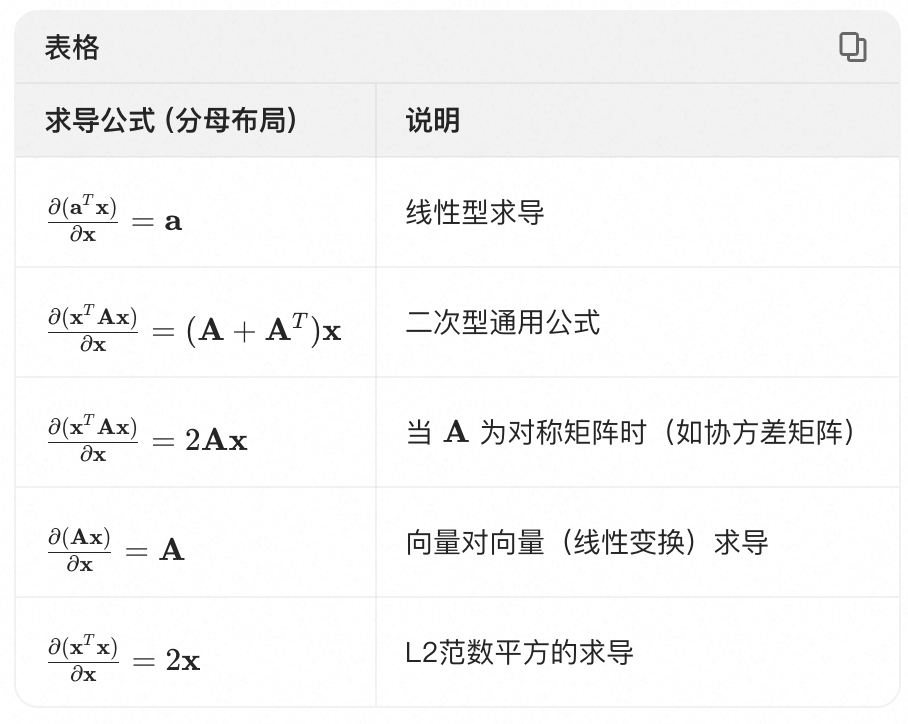

### 2.2
The gradient of $SSE$ with respect to $\mathbf{w}$ is:
$$
\frac{\partial SSE}{\partial \mathbf{w}} = -2\mathbf{X}^T(\mathbf{y} - \mathbf{X}\mathbf{w})
$$

### 2.3 
We set the gradient to be 0, and we can get:
$$
\mathbf{w} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}
$$

### 2.4
1. When the number of features is small, the closed-form solution can be computed efficiently. 
2. When:
   1. No inverse of $\mathbf{X}^T\mathbf{X}$
   2. High computational cost.

### 3.1
Assume that:
+ $y_i = \mathbf{w}^T\mathbf{x}_i + \epsilon_i$, where $\epsilon_i$ is the noise.
Then we have:
$$
-\log P(\mathbf{y} \mid \mathbf{X}) = -\log \prod_i P(y_i \mid \mathbf{x}_i) = -\sum_i \log P(y_i \mid \mathbf{x}_i) = -\sum_i \log P(\epsilon_i) = -\sum_i \log \frac{1}{2} \exp(-|\epsilon_i|) = \sum_i |\epsilon_i| + n\log 2 = \sum_i |y_i - \mathbf{w}^T\mathbf{x}_i| + n\log 2
$$

### 3.2 
The objective function is the sum of absolute errors (SAE):
$$
SAE = \sum_i |y_i - \hat{y}_i| = \sum_i |y_i - \mathbf{w}^T\mathbf{x}_i|
$$
The SAE is not differentiable at $\hat{y}_i = y_i$, so we consider to online update.


## 练习

1. 我们可以更深入地探讨指数族与softmax之间的联系。
    1. 计算softmax交叉熵损失$l(\mathbf{y},\hat{\mathbf{y}})$的二阶导数。
    1. 计算$\mathrm{softmax}(\mathbf{o})$给出的分布方差，并与上面计算的二阶导数匹配。
1. 假设我们有三个类发生的概率相等，即概率向量是$(\frac{1}{3}, \frac{1}{3}, \frac{1}{3})$。
    1. 如果我们尝试为它设计二进制代码，有什么问题？
    1. 请设计一个更好的代码。提示：如果我们尝试编码两个独立的观察结果会发生什么？如果我们联合编码$n$个观测值怎么办？
1. softmax是对上面介绍的映射的误称（虽然深度学习领域中很多人都使用这个名字）。真正的softmax被定义为$\mathrm{RealSoftMax}(a, b) = \log (\exp(a) + \exp(b))$。
    1. 证明$\mathrm{RealSoftMax}(a, b) > \mathrm{max}(a, b)$。
    1. 证明$\lambda^{-1} \mathrm{RealSoftMax}(\lambda a, \lambda b) > \mathrm{max}(a, b)$成立，前提是$\lambda > 0$。
    1. 证明对于$\lambda \to \infty$，有$\lambda^{-1} \mathrm{RealSoftMax}(\lambda a, \lambda b) \to \mathrm{max}(a, b)$。
    1. soft-min会是什么样子？
    1. 将其扩展到两个以上的数字。